In [4]:

import xgboost as xgb
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt


In [5]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df.head()
df['target'] = data.target
df.head()






,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
scaler = StandardScaler()
X = scaler.fit_transform(df.drop('target', axis=1))
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
model = xgb.XGBClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)  
print(f"Accuracy: {accuracy:.2f}")
classification_report_result = classification_report(y_test, y_pred)
print(classification_report_result)

Accuracy: 0.96
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



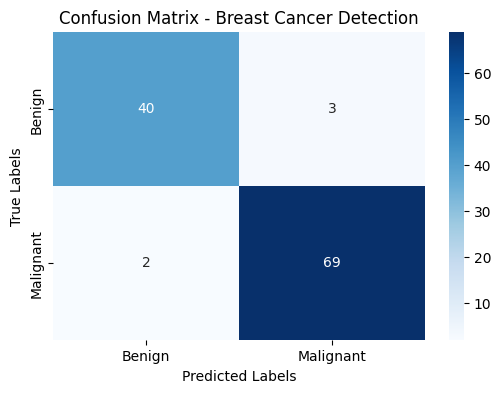

<Figure size 640x480 with 0 Axes>

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# y_test = true labels
# y_pred = predicted labels

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Breast Cancer Detection')
plt.show()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')





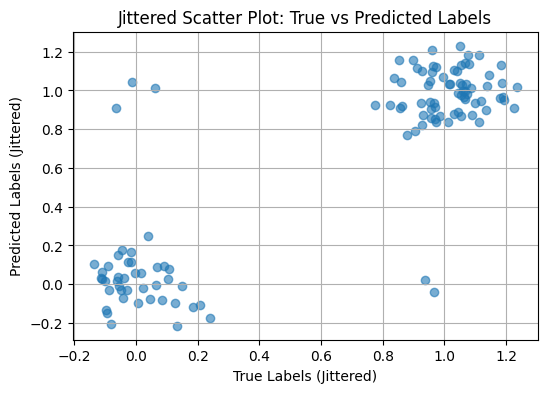

<Figure size 640x480 with 0 Axes>

In [9]:
import numpy as np

jitter = 0.1
y_test_jittered = y_test + np.random.normal(0, jitter, size=len(y_test))
y_pred_jittered = y_pred + np.random.normal(0, jitter, size=len(y_pred))

plt.figure(figsize=(6,4))
plt.scatter(y_test_jittered, y_pred_jittered, alpha=0.6)
plt.xlabel('True Labels (Jittered)')
plt.ylabel('Predicted Labels (Jittered)')
plt.title('Jittered Scatter Plot: True vs Predicted Labels')
plt.grid(True)
plt.show()
plt.savefig('jittered_scatter_plot.png', dpi=300, bbox_inches='tight')


In [10]:
import pickle

with open("xgb_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
